# Single-SRX cluster validation

This notebook walks through the cluster resolution selection process. Functions that orchestrate it are exposed in [cluster_validation](../../scripts/cluster_validation/__init__.py), and called both here and in the atlas workflow, outlined in [../../README.md](../../README.md).

The workflow for individual `h5ad` files from scBaseCount was developed before the atlas workflow, and as a result uses different orchestration functions.

The figures generated in this notebook call functions that are called in [resolution_validation.py](../../docs/report/scripts/resolution_validation.py), which generate [Supporting information S1](../../docs/report/si/resolution_validation.pdf) in [report](../../docs/report/report.pdf). The figures generated here should match those in [Supporting information S1](../../docs/report/si/resolution_validation.pdf).

See the methods section of the [report](../../docs/report/report.pdf) for details on the resolution selection methodology.

In [1]:
from io import BytesIO

import scanpy as sc
from IPython.display import Image, display
from cluster_validation import ClusterValidationConfig, run_cluster_validation_on_adata
from cluster_validation.viz import (
    plot_composition_bars,
    plot_metrics,
    plot_pca_cumvar,
    plot_resolution_sweep,
    plot_rf_confusion,
    plot_silhouette,
    plot_umap_merged,
    plot_umap_selected,
)
from shared.repo import REPO_ROOT

ROOT = REPO_ROOT


def show_fig(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    display(Image(buf.getvalue()))

## Configuration

Set `SRX` to the accession whose `{SRX}.h5ad` file is available in `H5AD_DIR`. There are a few individual files in `H5AD_DIR` that are committed to the repo, but if you want to try with a different file hosted at scBaseCount, you will need to download it and place it in `H5AD_DIR`.

In [2]:
SRX = "SRX26487579"
WEAK_PRIOR_KEY = "cell_type"
H5AD_DIR = ROOT / "data/scbasecount/2026-01-12/h5ad/GeneFull/Homo_sapiens"
H5AD_PATH = H5AD_DIR / f"{SRX}.h5ad"

if not H5AD_PATH.is_file():
    raise FileNotFoundError(f"h5ad not found: {H5AD_PATH.relative_to(ROOT)}")

print(f"Input: {H5AD_PATH.relative_to(ROOT)}")

Input: data/scbasecount/2026-01-12/h5ad/GeneFull/Homo_sapiens/SRX26487579.h5ad


## Run validation

Below, the orchestration function [run_cluster_validation_on_adata](../../scripts/cluster_validation/pipeline.py#L106-L107) is called. This function is not used in the atlas workflow. There are multiple reasons for this, outlined below:

- The atlas workflow implements batch correction with Harmony
- The single SRX workflow automatically selects the resolution with the highest matched-Jaccard score, while the atlas workflow instead exposes the highest maximum matched-Jaccard score for review before production.

Nonetheless, much of the code is shared between the single SRX and atlasworkflows. For instance:

- [matched-Jaccard scoring](../../scripts/cluster_validation/metrics.py#L19-L58)
- [PC selection](../../scripts/cluster_validation/embedding.py#L8-L50)

The cell below keeps the processed AnnData in memory and writes no replacement h5ad.

In [3]:
cfg = ClusterValidationConfig(
    srxAccession=SRX,
    localH5adRoot=H5AD_DIR,
    weakPriorKey=WEAK_PRIOR_KEY,
)
adata, result = run_cluster_validation_on_adata(
    sc.read_h5ad(H5AD_PATH),
    cfg,
    srx=SRX,
    write_outputs=False,
    plot=False,
)

{
    "srx": result.srxAccession,
    "selected_resolution": result.selectedResolution,
    "selected_clusters": result.nClustersPreMerge,
    "merged_clusters": result.nClustersPostMerge,
    "cells": result.nCellsFinal,
    "pcs": result.nPcs,
}

[2026-09-12 19:34:47] Starting cluster validation for SRX26487579
[2026-09-12 19:34:55] Done cluster validation for SRX26487579 with resolution 0.8 and 10 clusters and 50 PCs


{'srx': 'SRX26487579',
 'selected_resolution': 0.8,
 'selected_clusters': 19,
 'merged_clusters': 10,
 'cells': 1954,
 'pcs': 50}

## Figures

The SRX workflow defined a [ClusterValidationResult](../../scripts/cluster_validation/models.py#L8-L39) model, which stores the results of the cluster validation. Those results are displayed below.

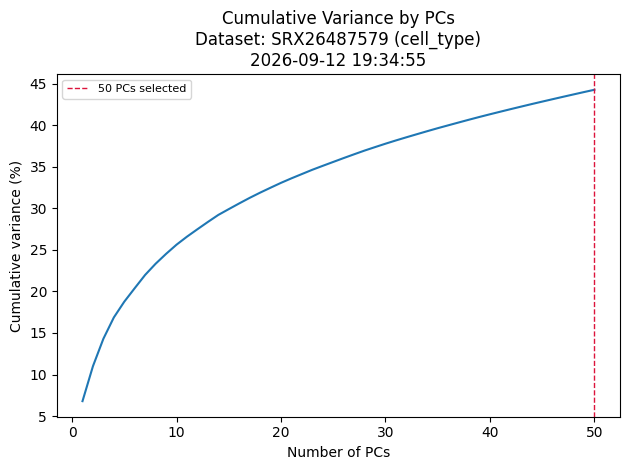

In [4]:
show_fig(plot_pca_cumvar(adata, result))

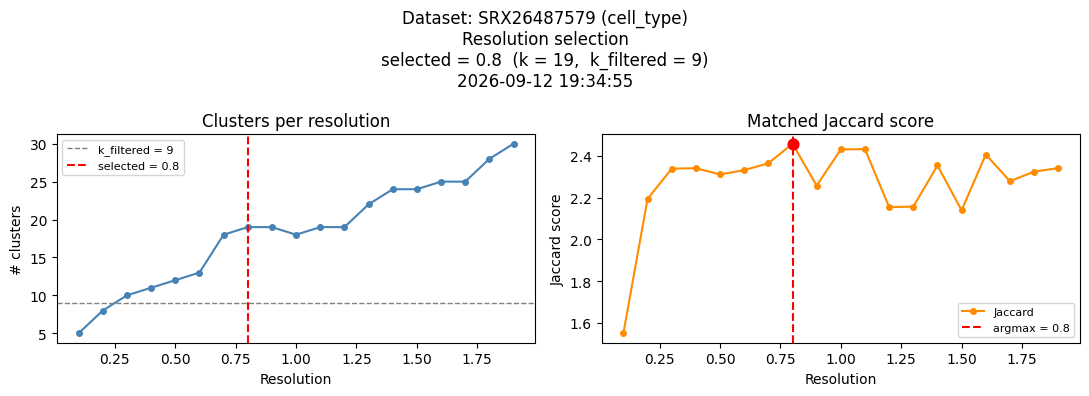

In [5]:
show_fig(plot_resolution_sweep(result))

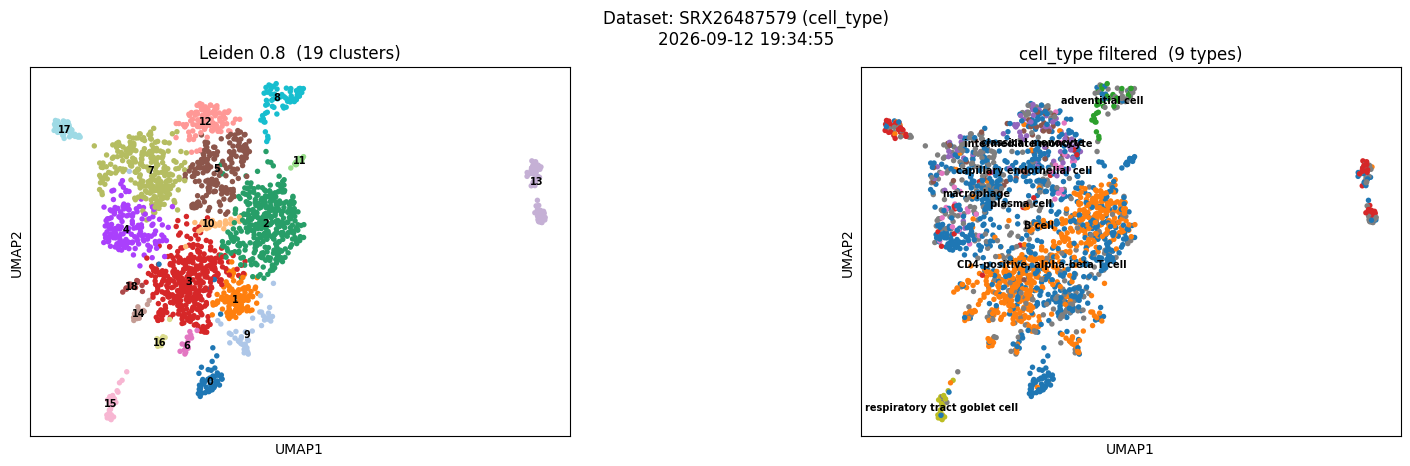

In [6]:
show_fig(plot_umap_selected(adata, result))

### RF merge

The random-forest merge is visualised below. The [pairwise confusion](../../scripts/cluster_validation/merge.py#L36-L86) was originally implemented by Parashar at Nygen, and was fitted to the individual SRX workflow by Oliver. It was not used in the atlas workflow.

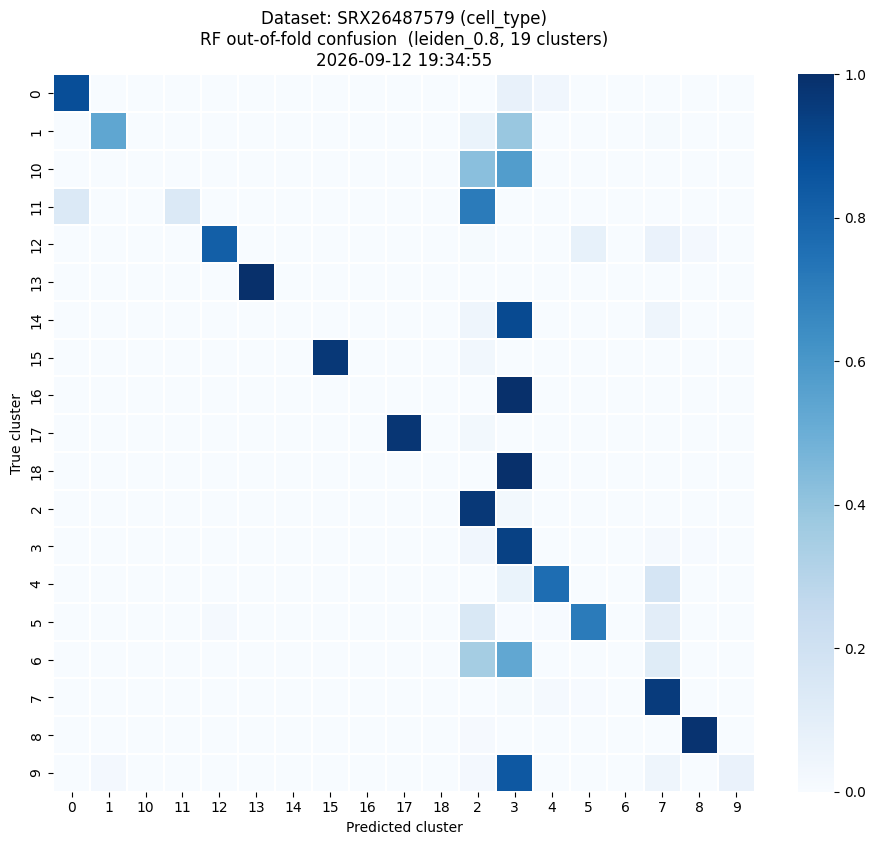

In [7]:
show_fig(plot_rf_confusion(result))

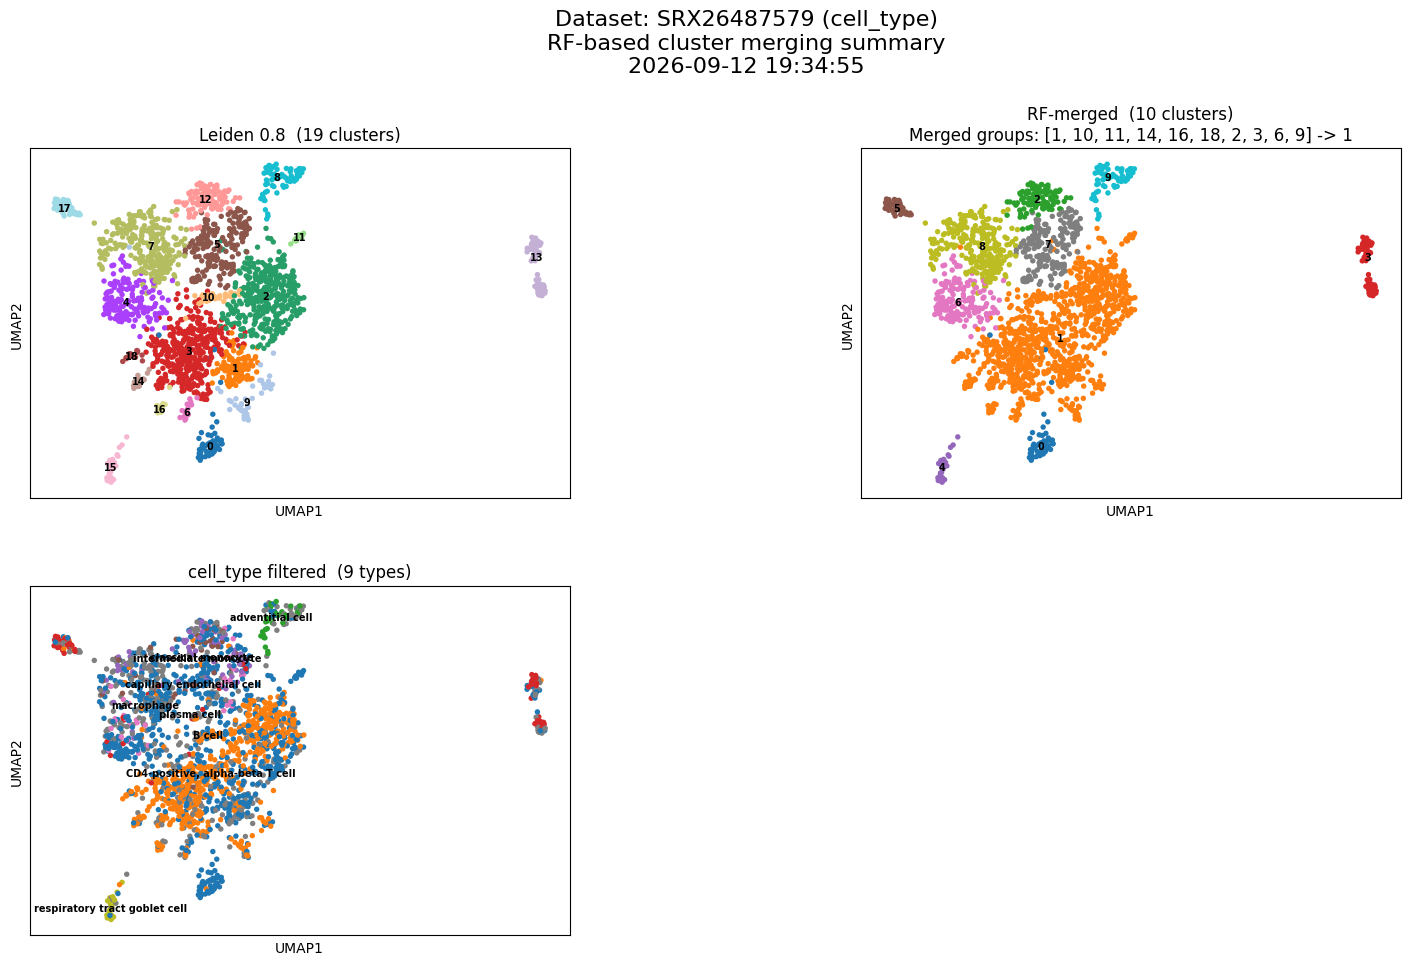

In [8]:
show_fig(plot_umap_merged(adata, result))

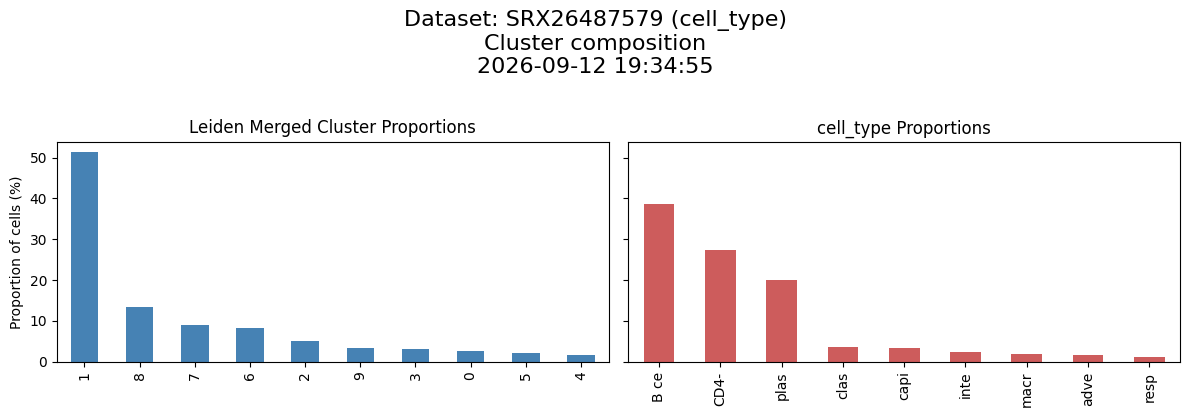

In [9]:
show_fig(plot_composition_bars(adata, result))

### Summary metrics

The cells below compute and display a suite of clustering metrics. These were used in method development as diagnostics.

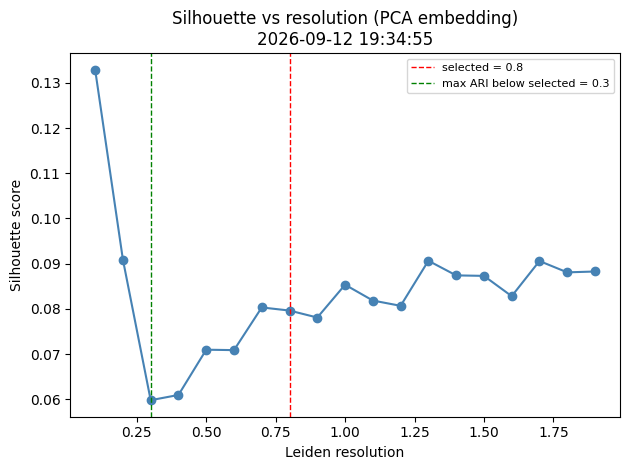

In [10]:
show_fig(plot_silhouette(result))

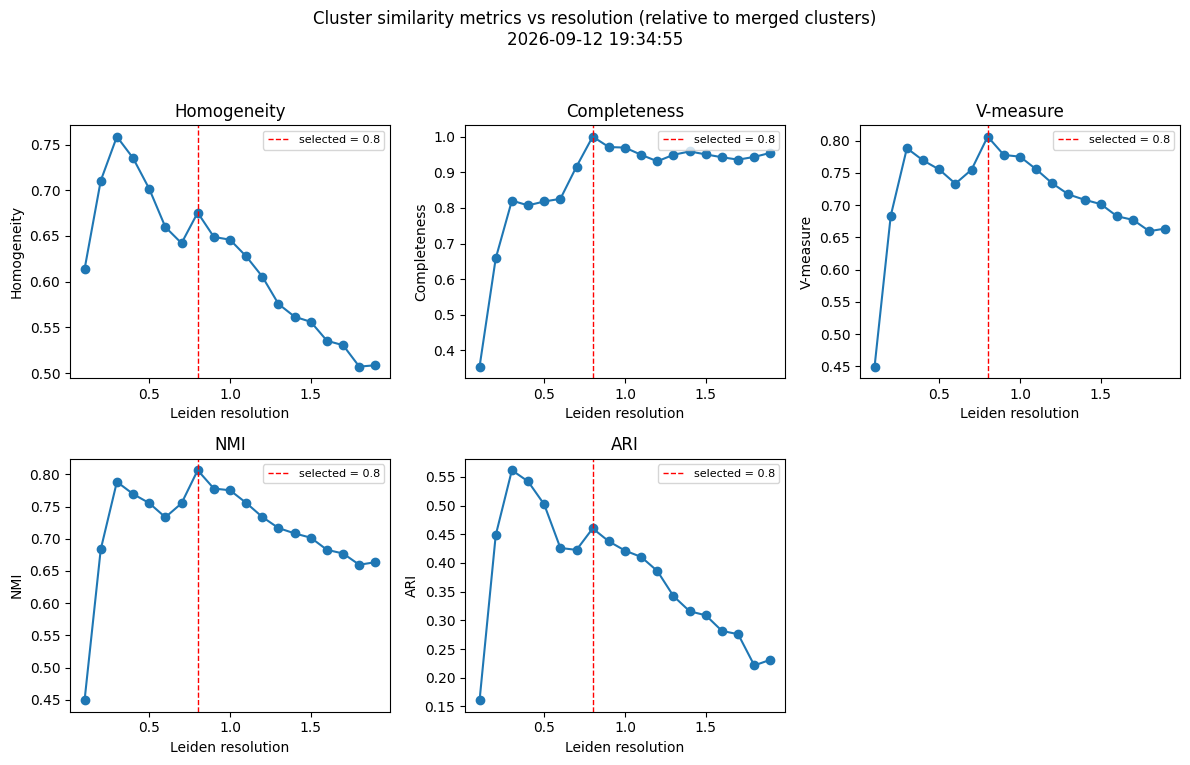

In [11]:
show_fig(plot_metrics(result))